Samples = 600
Scaled Current Range = -1.99967 3.7498899999999997

DFN + PRADA2013 RESULTS
RMSE      = 0.168642 V
MAE       = 0.112252 V
MAX ERROR = 0.801592 V


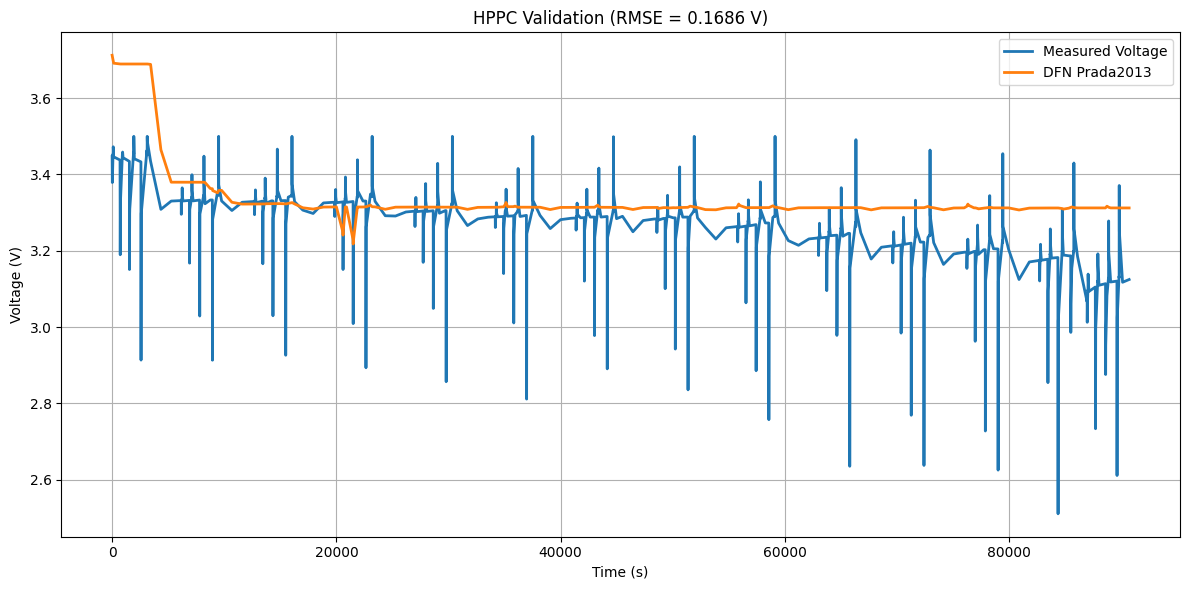

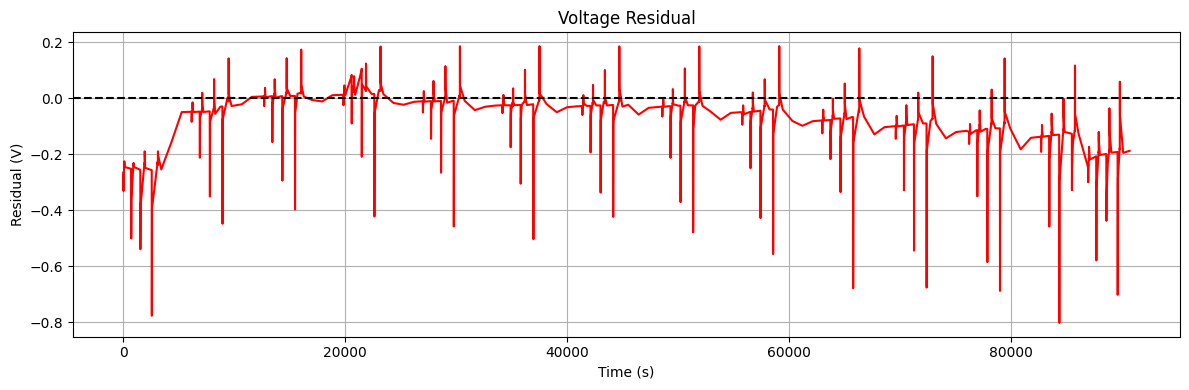

In [1]:
import pybamm
import numpy as np
import matplotlib.pyplot as plt

from scipy.io import loadmat
from scipy.interpolate import interp1d

# =====================================================
# LOAD HPPC DATA
# =====================================================

data = loadmat(
    "HPPC_5458.mat",
    squeeze_me=True,
    struct_as_record=False
)

meas = data["meas"]

time = np.asarray(meas.Time, dtype=float)
current = np.asarray(meas.Current, dtype=float)
voltage_measured = np.asarray(meas.Voltage, dtype=float)

# =====================================================
# CLEAN DATA
# =====================================================

time = time - time[0]

time, idx = np.unique(
    time,
    return_index=True
)

current = current[idx]
voltage_measured = voltage_measured[idx]

# =====================================================
# DOWNSAMPLE
# =====================================================

n_points = min(600, len(time))

idx = np.linspace(
    0,
    len(time) - 1,
    n_points
).astype(int)

time = time[idx]
current = current[idx]
voltage_measured = voltage_measured[idx]

# =====================================================
# SCALE CURRENT BY 10
# =====================================================

current = -current / 10.0

print("Samples =", len(time))
print(
    "Scaled Current Range =",
    current.min(),
    current.max()
)

# =====================================================
# DFN MODEL
# =====================================================

model = pybamm.lithium_ion.DFN()

params = pybamm.ParameterValues(
    "Prada2013"
)

params.update({
    "Upper voltage cut-off [V]": 5.0
})

current_function = pybamm.Interpolant(
    time,
    current,
    pybamm.t
)

params["Current function [A]"] = current_function

solver = pybamm.CasadiSolver(
    mode="safe"
)

sim = pybamm.Simulation(
    model,
    parameter_values=params,
    solver=solver
)

# =====================================================
# SOLVE
# =====================================================

solution = sim.solve(
    t_eval=np.linspace(
        0,
        float(time.max()),
        600
    )
)

# =====================================================
# VOLTAGE
# =====================================================

voltage_sim = solution[
    "Terminal voltage [V]"
].entries

voltage_sim_interp = interp1d(
    solution.t,
    voltage_sim,
    kind="linear",
    fill_value="extrapolate"
)(time)

# =====================================================
# METRICS
# =====================================================

rmse = np.sqrt(
    np.mean(
        (
            voltage_measured -
            voltage_sim_interp
        )**2
    )
)

mae = np.mean(
    np.abs(
        voltage_measured -
        voltage_sim_interp
    )
)

max_error = np.max(
    np.abs(
        voltage_measured -
        voltage_sim_interp
    )
)

print("\n==============================")
print("DFN + PRADA2013 RESULTS")
print("==============================")
print(f"RMSE      = {rmse:.6f} V")
print(f"MAE       = {mae:.6f} V")
print(f"MAX ERROR = {max_error:.6f} V")
print("==============================")

# =====================================================
# VOLTAGE CURVE
# =====================================================

plt.figure(figsize=(12,6))

plt.plot(
    time,
    voltage_measured,
    label="Measured Voltage",
    linewidth=2
)

plt.plot(
    time,
    voltage_sim_interp,
    label="DFN Prada2013",
    linewidth=2
)

plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title(
    f"HPPC Validation (RMSE = {rmse:.4f} V)"
)

plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

# =====================================================
# RESIDUAL
# =====================================================

residual = (
    voltage_measured -
    voltage_sim_interp
)

plt.figure(figsize=(12,4))

plt.plot(
    time,
    residual,
    color="red"
)

plt.axhline(
    0,
    linestyle="--",
    color="black"
)

plt.xlabel("Time (s)")
plt.ylabel("Residual (V)")
plt.title("Voltage Residual")

plt.grid(True)
plt.tight_layout()

plt.show()